In [1]:
from pathlib import Path
import random
import shutil

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
WAID_DIR = DATA_RAW / "waid"
COCO_DIR = DATA_RAW / "coco_cow_sheep" / "exported"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_CROPS = PROJECT_ROOT / "data" / "crops"

CLASS_MAP = {0: "cattle", 1: "sheep"}
CLASS_MAP_INV = {"cattle": 0, "sheep": 1}
KEEP_CLASSES = {"cattle", "sheep", "cow"}
SPLIT_TRAIN, SPLIT_VAL, SPLIT_TEST = 0.70, 0.15, 0.15
MIN_BBOX_AREA = 0.001
MAX_CROPS_PER_IMAGE = 5

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)

print("project root:", PROJECT_ROOT)
print("class map:", CLASS_MAP)


project root: /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova
class map: {0: 'cattle', 1: 'sheep'}


In [2]:
with open(WAID_DIR / "data.yaml") as f:
    waid_meta = yaml.safe_load(f)
waid_names = waid_meta["names"]

with open(COCO_DIR / "dataset.yaml") as f:
    coco_meta = yaml.safe_load(f)
coco_names = coco_meta["names"]


def name_from(names, cls_id):
    if isinstance(names, dict):
        return names.get(cls_id, f"cls_{cls_id}")
    if isinstance(names, list) and 0 <= cls_id < len(names):
        return names[cls_id]
    return f"cls_{cls_id}"


def load_labels(lbl_path, names):
    rows = []
    if not lbl_path.exists():
        return rows
    for line in lbl_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls_id = int(parts[0])
        cls_name = name_from(names, cls_id).lower()
        if cls_name == "cow":
            cls_name = "cattle"
        if cls_name not in KEEP_CLASSES or cls_name == "cow":
            continue
        cx, cy, w, h = map(float, parts[1:5])
        rows.append({
            "class": cls_name if cls_name != "cow" else "cattle",
            "cx": cx, "cy": cy, "w": w, "h": h,
        })
    return rows


def build_image_index():
    records = []
    for split in ("train", "valid", "test"):
        imgs_dir = WAID_DIR / split / "images"
        lbls_dir = WAID_DIR / split / "labels"
        for img in imgs_dir.glob("*.jpg"):
            lbl = lbls_dir / (img.stem + ".txt")
            boxes = load_labels(lbl, waid_names)
            if not boxes:
                continue
            records.append({"source": "waid", "image_path": str(img), "boxes": boxes})
    coco_imgs = COCO_DIR / "images" / "val"
    coco_lbls = COCO_DIR / "labels" / "val"
    for img in coco_imgs.glob("*"):
        if img.suffix.lower() not in (".jpg", ".jpeg", ".png"):
            continue
        lbl = coco_lbls / (img.stem + ".txt")
        boxes = load_labels(lbl, coco_names)
        if not boxes:
            continue
        records.append({"source": "coco", "image_path": str(img), "boxes": boxes})
    return pd.DataFrame(records)


index_df = build_image_index()
index_df["n_boxes"] = index_df["boxes"].apply(len)
index_df["primary_class"] = index_df["boxes"].apply(lambda bs: bs[0]["class"])
print("images kept after filtering to cattle/sheep:", len(index_df))
print("by source:", index_df["source"].value_counts().to_dict())
print("by primary class:", index_df["primary_class"].value_counts().to_dict())
index_df.head()


images kept after filtering to cattle/sheep: 12232
by source: {'waid': 8839, 'coco': 3393}
by primary class: {'cattle': 6548, 'sheep': 5684}


,source,image_path,boxes,n_boxes,primary_class
0,waid,/Users/m/Documents/capstone-msc-da-feb-25-coho...,"[{'class': 'cattle', 'cx': 0.6671875, 'cy': 0....",19,cattle
1,waid,/Users/m/Documents/capstone-msc-da-feb-25-coho...,"[{'class': 'cattle', 'cx': 0.80859375, 'cy': 0...",8,cattle
2,waid,/Users/m/Documents/capstone-msc-da-feb-25-coho...,"[{'class': 'cattle', 'cx': 0.58046875, 'cy': 0...",29,cattle
3,waid,/Users/m/Documents/capstone-msc-da-feb-25-coho...,"[{'class': 'sheep', 'cx': 0.22265625, 'cy': 0....",37,sheep
4,waid,/Users/m/Documents/capstone-msc-da-feb-25-coho...,"[{'class': 'sheep', 'cx': 0.503125, 'cy': 0.04...",20,sheep


In [3]:
MERGED_DIR = DATA_RAW / "merged"
MERGED_IMG = MERGED_DIR / "images"
MERGED_LBL = MERGED_DIR / "labels"
shutil.rmtree(MERGED_DIR, ignore_errors=True)
MERGED_IMG.mkdir(parents=True, exist_ok=True)
MERGED_LBL.mkdir(parents=True, exist_ok=True)

merged_paths = []
for i, row in index_df.iterrows():
    src_img = Path(row["image_path"])
    stem = f"{row['source']}_{i:06d}"
    dst_img = MERGED_IMG / (stem + src_img.suffix)
    shutil.copy(src_img, dst_img)
    lines = []
    for b in row["boxes"]:
        cls_id = CLASS_MAP_INV[b["class"]]
        lines.append(f"{cls_id} {b['cx']:.6f} {b['cy']:.6f} {b['w']:.6f} {b['h']:.6f}")
    (MERGED_LBL / (stem + ".txt")).write_text("\n".join(lines) + "\n")
    merged_paths.append(str(dst_img))

index_df["merged_path"] = merged_paths
print("merged images copied:", len(list(MERGED_IMG.glob('*'))))
print("merged labels copied:", len(list(MERGED_LBL.glob('*'))))


merged images copied: 12232
merged labels copied: 12232


In [4]:
for split in ("train", "val", "test"):
    (DATA_PROCESSED / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATA_PROCESSED / "labels" / split).mkdir(parents=True, exist_ok=True)

train_imgs, temp_imgs, train_cls, temp_cls = train_test_split(
    index_df["merged_path"].tolist(),
    index_df["primary_class"].tolist(),
    train_size=SPLIT_TRAIN,
    stratify=index_df["primary_class"].tolist(),
    random_state=SEED,
)
val_ratio_temp = SPLIT_VAL / (SPLIT_VAL + SPLIT_TEST)
val_imgs, test_imgs, val_cls, test_cls = train_test_split(
    temp_imgs, temp_cls,
    train_size=val_ratio_temp, stratify=temp_cls, random_state=SEED,
)

split_map = {}
for p in train_imgs: split_map[p] = "train"
for p in val_imgs:   split_map[p] = "val"
for p in test_imgs:  split_map[p] = "test"
index_df["split"] = index_df["merged_path"].map(split_map)


def place(paths, split):
    for p in paths:
        src = Path(p)
        shutil.copy(src, DATA_PROCESSED / "images" / split / src.name)
        lbl_src = MERGED_LBL / (src.stem + ".txt")
        shutil.copy(lbl_src, DATA_PROCESSED / "labels" / split / (src.stem + ".txt"))


place(train_imgs, "train")
place(val_imgs, "val")
place(test_imgs, "test")

print("split sizes (images):")
print(f"  train: {len(train_imgs)}")
print(f"  val:   {len(val_imgs)}")
print(f"  test:  {len(test_imgs)}")

print()
print("class balance per split:")
for split, ys in [("train", train_cls), ("val", val_cls), ("test", test_cls)]:
    s = pd.Series(ys).value_counts()
    print(f"  {split}: {s.to_dict()}")

data_yaml = {
    "path": str(DATA_PROCESSED.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {0: "cattle", 1: "sheep"},
}
with open(DATA_PROCESSED / "data.yaml", "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)
print("wrote", DATA_PROCESSED / "data.yaml")


split sizes (images):
  train: 8562
  val:   1835
  test:  1835

class balance per split:
  train: {'cattle': 4583, 'sheep': 3979}
  val: {'cattle': 982, 'sheep': 853}
  test: {'cattle': 983, 'sheep': 852}
wrote /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/data/processed/data.yaml


In [5]:
for split in ("train", "val", "test"):
    for name in ("cattle", "sheep"):
        (DATA_CROPS / split / name).mkdir(parents=True, exist_ok=True)

n_crops = {"train": {"cattle": 0, "sheep": 0},
           "val":   {"cattle": 0, "sheep": 0},
           "test":  {"cattle": 0, "sheep": 0}}
n_skipped_small = 0
n_skipped_tiny_crop = 0

for _, row in index_df.iterrows():
    split = row["split"]
    img_path = Path(row["image_path"])
    image = Image.open(img_path).convert("RGB")
    W, H = image.size
    boxes = row["boxes"]
    boxes_sorted = sorted(boxes, key=lambda b: -b["w"] * b["h"])
    used = 0
    for b in boxes_sorted:
        if used >= MAX_CROPS_PER_IMAGE:
            break
        area = b["w"] * b["h"]
        if area < MIN_BBOX_AREA:
            n_skipped_small += 1
            continue
        cls = b["class"]
        x1 = int((b["cx"] - b["w"] / 2) * W)
        y1 = int((b["cy"] - b["h"] / 2) * H)
        x2 = int((b["cx"] + b["w"] / 2) * W)
        y2 = int((b["cy"] + b["h"] / 2) * H)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        if x2 - x1 < 10 or y2 - y1 < 10:
            n_skipped_tiny_crop += 1
            continue
        crop = image.crop((x1, y1, x2, y2))
        out_name = f"{img_path.stem}_{used}.jpg"
        crop.save(DATA_CROPS / split / cls / out_name, quality=90)
        n_crops[split][cls] += 1
        used += 1

print("crops per split / class:")
for split in ("train", "val", "test"):
    print(f"  {split}: {n_crops[split]}")
print(f"skipped (area < {MIN_BBOX_AREA}): {n_skipped_small}")
print(f"skipped (pixel < 10): {n_skipped_tiny_crop}")


crops per split / class:
  train: {'cattle': 18755, 'sheep': 17051}
  val: {'cattle': 4107, 'sheep': 3663}
  test: {'cattle': 4124, 'sheep': 3620}
skipped (area < 0.001): 5306
skipped (pixel < 10): 13


In [6]:
def lighting_label(img_rgb):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    v = hsv[..., 2].mean() / 255.0
    if v < 0.35:
        return "dim"
    if v < 0.65:
        return "overcast"
    return "bright"


def box_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def occlusion_label(boxes_yolo):
    xyxy = []
    for b in boxes_yolo:
        cx, cy, w, h = b["cx"], b["cy"], b["w"], b["h"]
        xyxy.append((cx - w/2, cy - h/2, cx + w/2, cy + h/2))
    if len(xyxy) < 2:
        return "low"
    max_iou = 0.0
    for i in range(len(xyxy)):
        for j in range(i + 1, len(xyxy)):
            max_iou = max(max_iou, box_iou(xyxy[i], xyxy[j]))
    if max_iou < 0.1:
        return "low"
    if max_iou < 0.3:
        return "medium"
    return "high"


rows = []
for _, row in index_df.iterrows():
    img_bgr = cv2.imread(row["image_path"])
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    rows.append({
        "image_id": Path(row["image_path"]).name,
        "source": row["source"],
        "split": row["split"],
        "primary_class": row["primary_class"],
        "n_boxes": row["n_boxes"],
        "lighting": lighting_label(img_rgb),
        "occlusion": occlusion_label(row["boxes"]),
    })

subgroup_df = pd.DataFrame(rows)
subgroup_csv = DATA_PROCESSED / "subgroup_labels.csv"
subgroup_df.to_csv(subgroup_csv, index=False)

print("wrote", subgroup_csv, "rows:", len(subgroup_df))
print()
print("lighting counts:")
print(subgroup_df["lighting"].value_counts())
print()
print("occlusion counts:")
print(subgroup_df["occlusion"].value_counts())
print()
print("lighting x split:")
print(pd.crosstab(subgroup_df["split"], subgroup_df["lighting"]))
print()
print("occlusion x split:")
print(pd.crosstab(subgroup_df["split"], subgroup_df["occlusion"]))


wrote /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/data/processed/subgroup_labels.csv rows: 12232

lighting counts:
lighting
overcast    9652
dim         1395
bright      1185
Name: count, dtype: int64

occlusion counts:
occlusion
low       6259
medium    3074
high      2899
Name: count, dtype: int64

lighting x split:
lighting  bright  dim  overcast
split                          
test         196  206      1433
train        809  964      6789
val          180  225      1430

occlusion x split:
occlusion  high   low  medium
split                        
test        433   960     442
train      2027  4376    2159
val         439   923     473


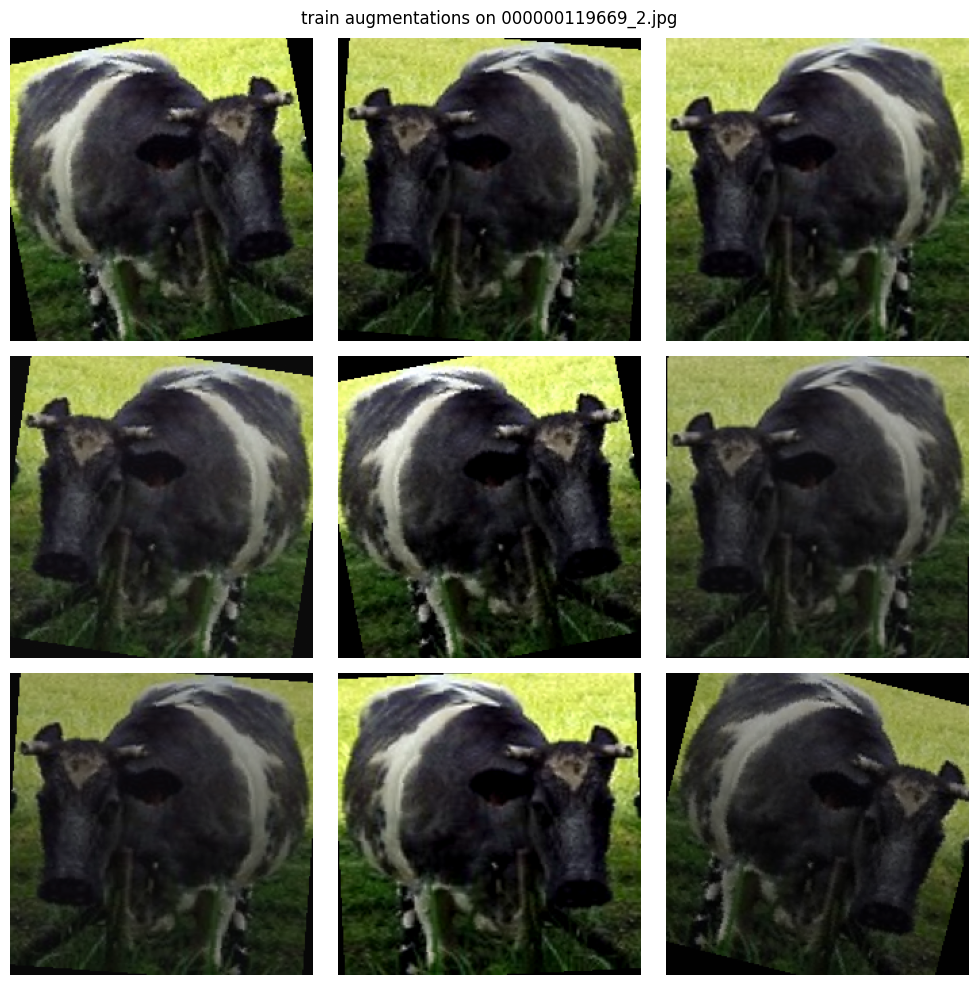

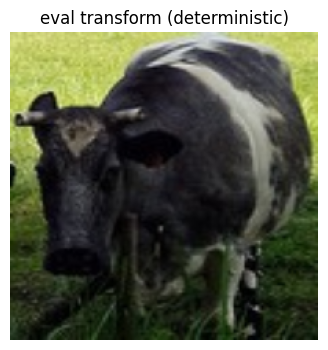

In [7]:
from torchvision import transforms
import torch

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def unnormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


sample_crops = list((DATA_CROPS / "train" / "cattle").glob("*.jpg"))
sample_path = sample_crops[0] if sample_crops else None

if sample_path is not None:
    img = Image.open(sample_path).convert("RGB")
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for ax in axes.flatten():
        t = train_transform(img)
        ax.imshow(unnormalize(t))
        ax.axis("off")
    fig.suptitle(f"train augmentations on {sample_path.name}")
    plt.tight_layout()
    plt.show()

    t_eval = eval_transform(img)
    plt.figure(figsize=(4, 4))
    plt.imshow(unnormalize(t_eval))
    plt.axis("off")
    plt.title("eval transform (deterministic)")
    plt.show()
else:
    print("no crop found to demo transforms on")


In [8]:
print("summary")
print()
print("processed dataset:")
for split in ("train", "val", "test"):
    n = len(list((DATA_PROCESSED / "images" / split).glob("*")))
    print(f"  {split}: {n} images")

print()
print("classification crops:")
for split in ("train", "val", "test"):
    per_class = {c: len(list((DATA_CROPS / split / c).glob('*'))) for c in ("cattle", "sheep")}
    total = sum(per_class.values())
    print(f"  {split}: total={total}, {per_class}")

print()
print("subgroup labels file:", DATA_PROCESSED / "subgroup_labels.csv")
print("data yaml for YOLO:  ", DATA_PROCESSED / "data.yaml")

print()
print("class imbalance (train):")
train_class_counts = {c: len(list((DATA_CROPS / 'train' / c).glob('*'))) for c in ("cattle", "sheep")}
total = sum(train_class_counts.values())
for c, n in train_class_counts.items():
    print(f"  {c}: {n} ({n/total*100:.1f}%)")


summary

processed dataset:
  train: 8562 images
  val: 1835 images
  test: 1835 images

classification crops:
  train: total=35806, {'cattle': 18755, 'sheep': 17051}


  val: total=7770, {'cattle': 4107, 'sheep': 3663}
  test: total=7744, {'cattle': 4124, 'sheep': 3620}

subgroup labels file: /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/data/processed/subgroup_labels.csv
data yaml for YOLO:   /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/data/processed/data.yaml

class imbalance (train):
  cattle: 18755 (52.4%)
  sheep: 17051 (47.6%)
